# Task 1: Chaotic Dynamical Systems


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

# Set plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True


## Part A: Discrete Chaotic Systems
### A.2 Logistic Map


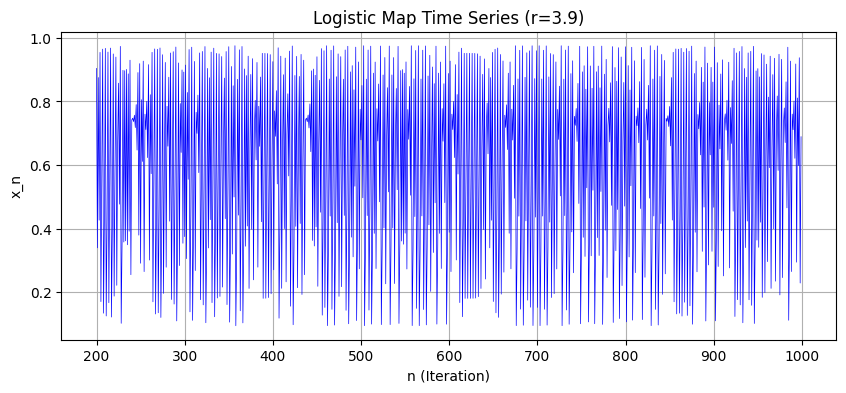

In [2]:
# Logistic Map Time Series
def logistic_map(r, x, iterations):
    history = np.zeros(iterations)
    history[0] = x
    for i in range(1, iterations):
        history[i] = r * history[i-1] * (1 - history[i-1])
    return history

iterations = 1000
transient = 200
r_chaotic = 3.9
x0 = 0.5

x_history = logistic_map(r_chaotic, x0, iterations)

plt.figure(figsize=(10, 4))
plt.plot(range(transient, iterations), x_history[transient:], lw=0.5, color='blue')
plt.title(f'Logistic Map Time Series (r={r_chaotic})')
plt.xlabel('n (Iteration)')
plt.ylabel('x_n')
plt.show()


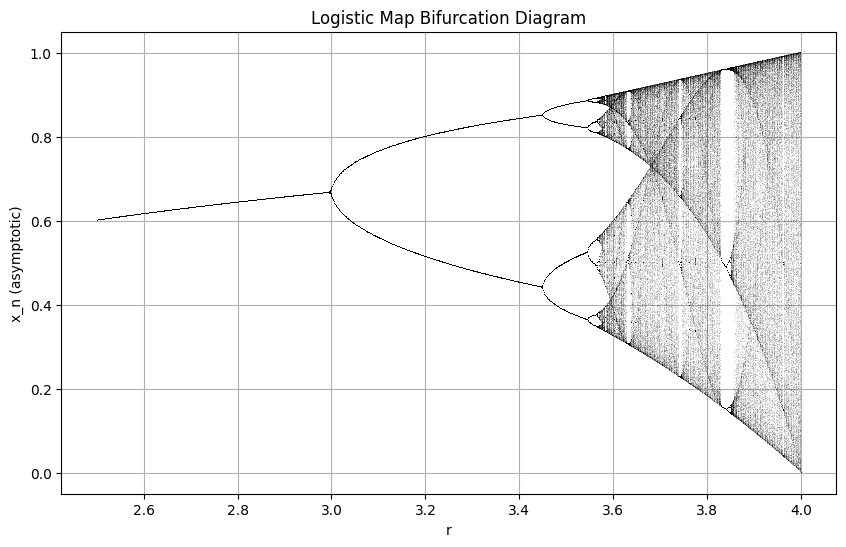

In [3]:
# Logistic Map Bifurcation Diagram
r_values = np.linspace(2.5, 4.0, 1000)
iterations_bif = 1000
transient_bif = 500

plt.figure(figsize=(10, 6))
for r in r_values:
    # We can simulate slightly faster by using numpy arrays directly if we wanted, 
    # but a simple loop per r value is fine for this resolution.
    x = 0.5
    # Transient
    for _ in range(transient_bif):
        x = r * x * (1 - x)
    # Collect points
    x_points = np.zeros(iterations_bif - transient_bif)
    for i in range(iterations_bif - transient_bif):
        x = r * x * (1 - x)
        x_points[i] = x
    plt.plot([r] * len(x_points), x_points, ',k', alpha=0.1)

plt.title('Logistic Map Bifurcation Diagram')
plt.xlabel('r')
plt.ylabel('x_n (asymptotic)')
plt.show()


### A.3 Hénon Map


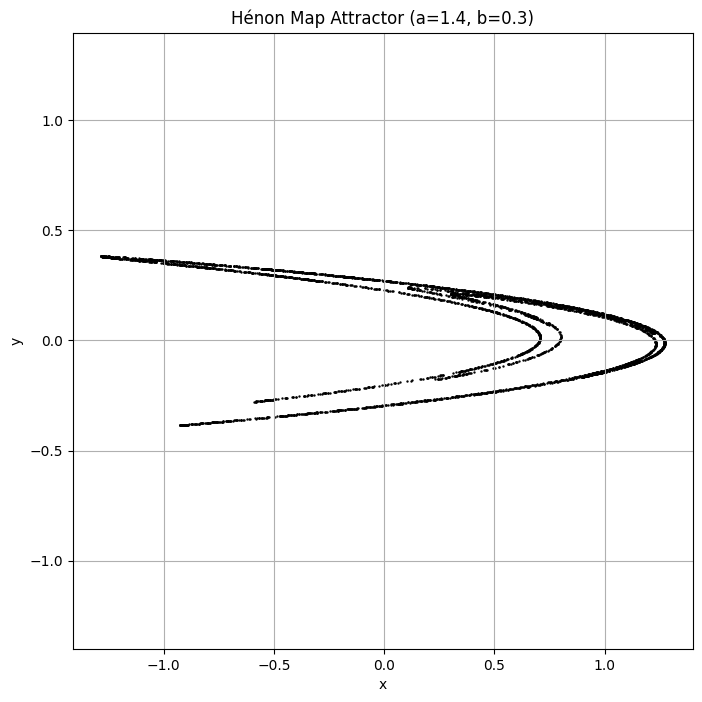

In [4]:
# Hénon Map Attractor
def henon_map(a, b, x0, y0, iterations):
    x_hist = np.zeros(iterations)
    y_hist = np.zeros(iterations)
    x_hist[0], y_hist[0] = x0, y0
    for i in range(1, iterations):
        x_hist[i] = 1 - a * x_hist[i-1]**2 + y_hist[i-1]
        y_hist[i] = b * x_hist[i-1]
    return x_hist, y_hist

a, b = 1.4, 0.3
iters_henon = 5000
transient_henon = 500

xh, yh = henon_map(a, b, 0, 0, iters_henon)

plt.figure(figsize=(8, 8))
plt.scatter(xh[transient_henon:], yh[transient_henon:], s=0.5, color='black')
plt.title(f'Hénon Map Attractor (a={a}, b={b})')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()


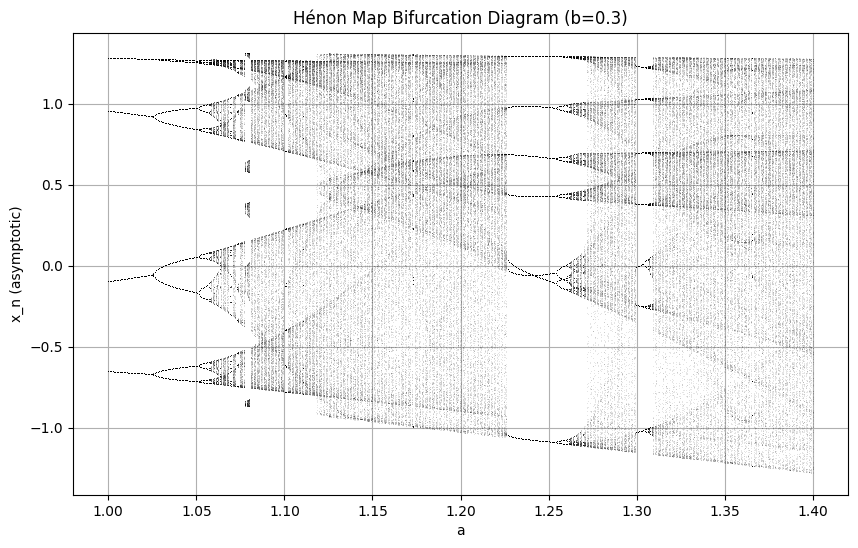

In [5]:
# Hénon Map Bifurcation Diagram
a_values = np.linspace(1.0, 1.4, 500)
b_fixed = 0.3
iters_henon_bif = 1000
trans_henon_bif = 500

plt.figure(figsize=(10, 6))
for a_val in a_values:
    x, y = 0.0, 0.0
    for _ in range(trans_henon_bif):
        x_new = 1 - a_val * x**2 + y
        y = b_fixed * x
        x = x_new
        
    x_points = np.zeros(iters_henon_bif - trans_henon_bif)
    for i in range(iters_henon_bif - trans_henon_bif):
        x_new = 1 - a_val * x**2 + y
        y = b_fixed * x
        x = x_new
        x_points[i] = x
        
    plt.plot([a_val] * len(x_points), x_points, ',k', alpha=0.1)

plt.title('Hénon Map Bifurcation Diagram (b=0.3)')
plt.xlabel('a')
plt.ylabel('x_n (asymptotic)')
plt.show()


## Part B: Continuous Chaotic Systems
### B.2 Lorenz System


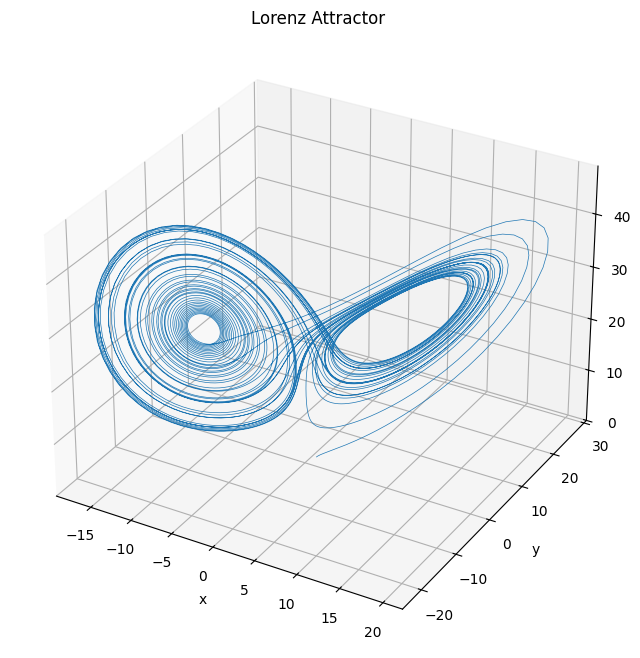

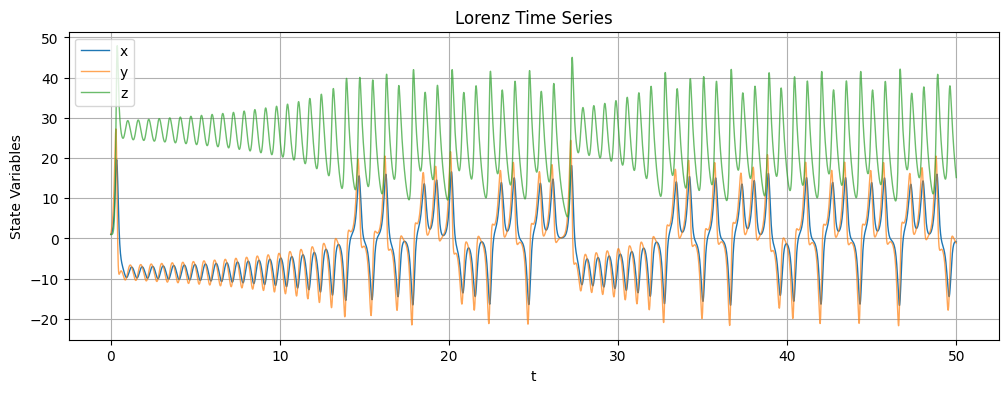

In [6]:
# Lorenz System
def lorenz(t, state, sigma, rho, beta):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

sigma, rho, beta = 10, 28, 8/3
state0 = [1, 1, 1]
t_span = (0, 50)
dt = 0.01
t_eval = np.arange(t_span[0], t_span[1], dt)

sol_lorenz = solve_ivp(lorenz, t_span, state0, args=(sigma, rho, beta), t_eval=t_eval, method='RK45')

# 3D Phase Space
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(sol_lorenz.y[0], sol_lorenz.y[1], sol_lorenz.y[2], lw=0.5)
ax.set_title('Lorenz Attractor')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

# Time Series
plt.figure(figsize=(12, 4))
plt.plot(sol_lorenz.t, sol_lorenz.y[0], label='x', lw=1)
plt.plot(sol_lorenz.t, sol_lorenz.y[1], label='y', lw=1, alpha=0.7)
plt.plot(sol_lorenz.t, sol_lorenz.y[2], label='z', lw=1, alpha=0.7)
plt.title('Lorenz Time Series')
plt.xlabel('t')
plt.ylabel('State Variables')
plt.legend()
plt.show()


### B.3 Rössler System


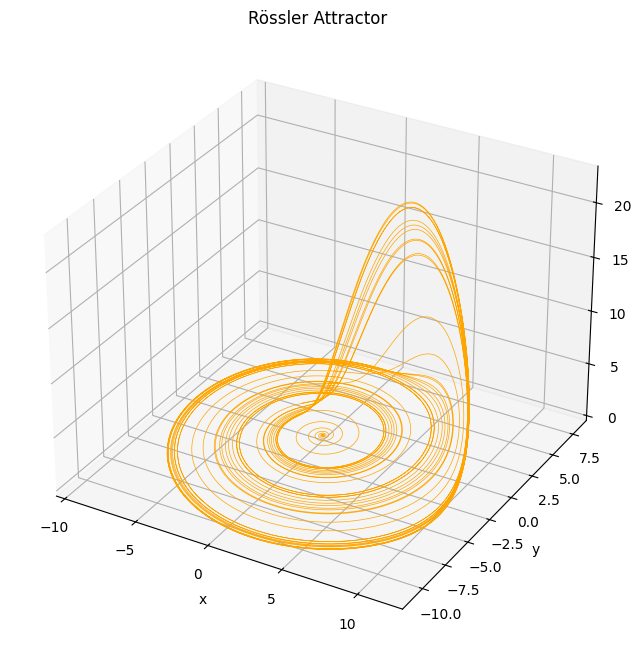

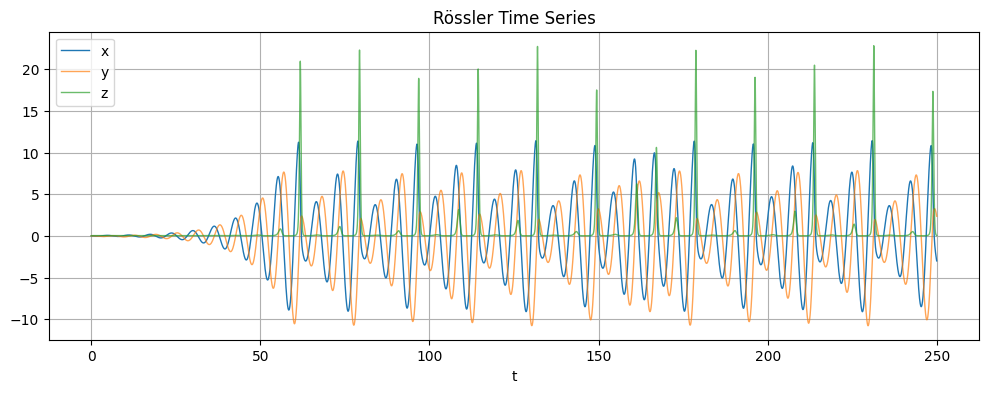

In [7]:
# Rössler System
def rossler(t, state, a, b, c):
    x, y, z = state
    dxdt = -y - z
    dydt = x + a * y
    dzdt = b + z * (x - c)
    return [dxdt, dydt, dzdt]

a_r, b_r, c_r = 0.2, 0.2, 5.7
state0_ross = [0, 0, 0]
t_span_ross = (0, 250)
dt_ross = 0.01
t_eval_ross = np.arange(t_span_ross[0], t_span_ross[1], dt_ross)

sol_ross = solve_ivp(rossler, t_span_ross, state0_ross, args=(a_r, b_r, c_r), t_eval=t_eval_ross, method='RK45')

# 3D Phase Space
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(sol_ross.y[0], sol_ross.y[1], sol_ross.y[2], lw=0.5, color='orange')
ax.set_title('Rössler Attractor')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

# Time Series
plt.figure(figsize=(12, 4))
plt.plot(sol_ross.t, sol_ross.y[0], label='x', lw=1)
plt.plot(sol_ross.t, sol_ross.y[1], label='y', lw=1, alpha=0.7)
plt.plot(sol_ross.t, sol_ross.y[2], label='z', lw=1, alpha=0.7)
plt.title('Rössler Time Series')
plt.xlabel('t')
plt.legend()
plt.show()


### B.4 Chen System


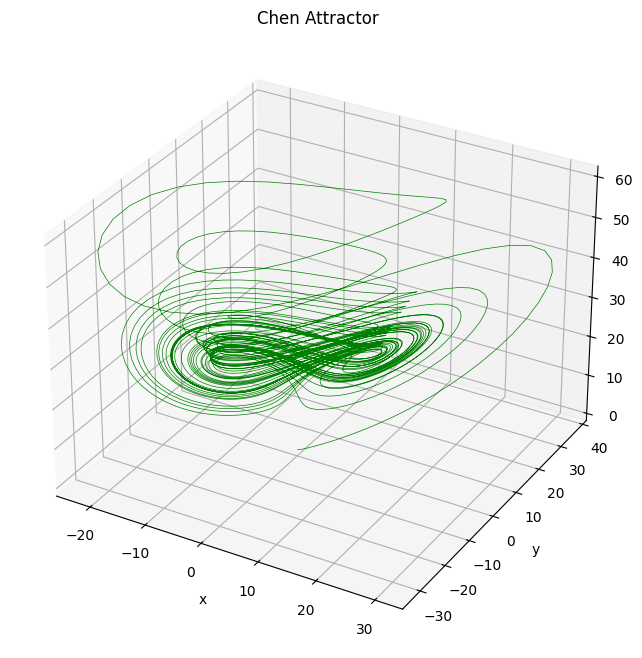

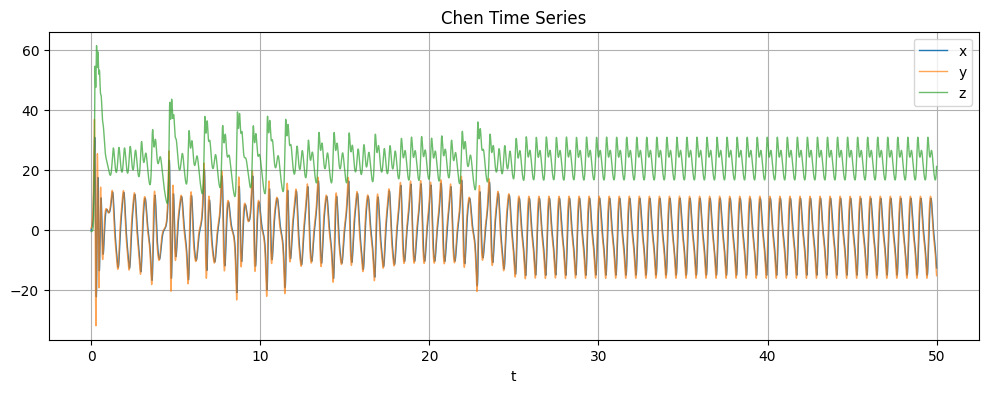

In [8]:
# Chen System
def chen(t, state, a, b, c):
    x, y, z = state
    dxdt = a * (y - x)
    dydt = (c - a) * x - x * z + c * y
    dzdt = x * y - b * z
    return [dxdt, dydt, dzdt]

a_c, b_c, c_c = 35, 3, 28
state0_chen = [-0.1, 0.5, -0.6]
t_span_chen = (0, 50)
dt_chen = 0.005
t_eval_chen = np.arange(t_span_chen[0], t_span_chen[1], dt_chen)

sol_chen = solve_ivp(chen, t_span_chen, state0_chen, args=(a_c, b_c, c_c), t_eval=t_eval_chen, method='RK45')

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(sol_chen.y[0], sol_chen.y[1], sol_chen.y[2], lw=0.5, color='green')
ax.set_title('Chen Attractor')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(sol_chen.t, sol_chen.y[0], label='x', lw=1)
plt.plot(sol_chen.t, sol_chen.y[1], label='y', lw=1, alpha=0.7)
plt.plot(sol_chen.t, sol_chen.y[2], label='z', lw=1, alpha=0.7)
plt.title('Chen Time Series')
plt.xlabel('t')
plt.legend()
plt.show()


### B.5 Hyperchaotic Rössler System


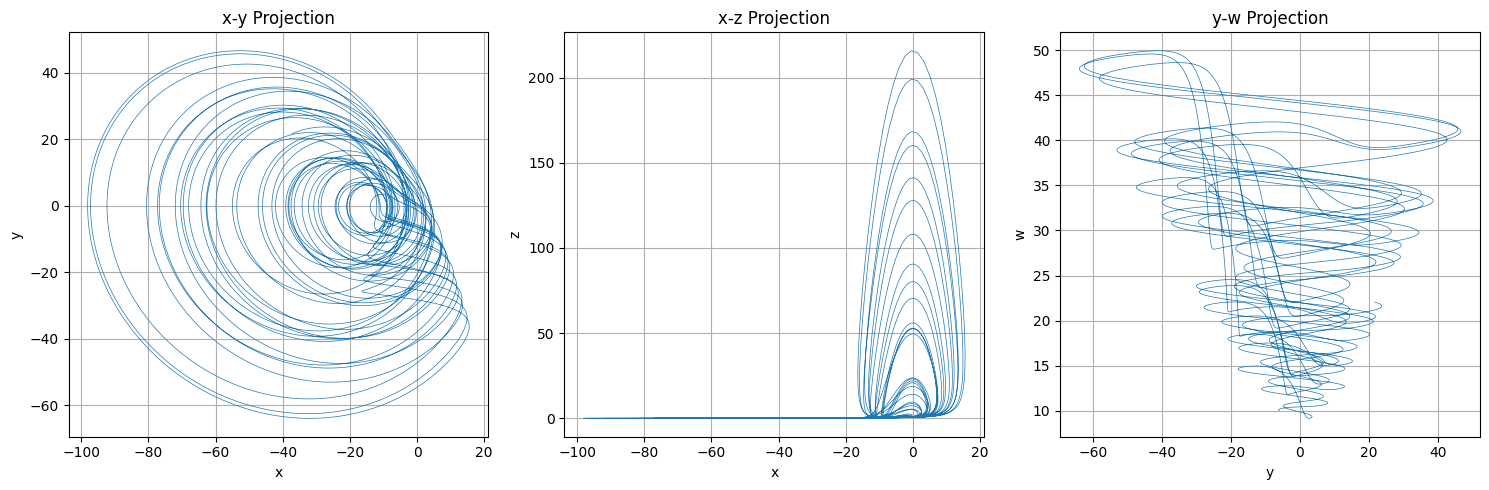

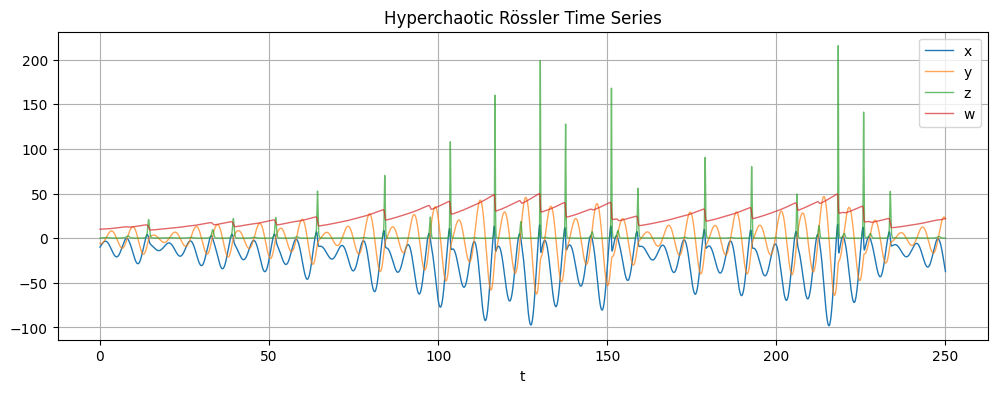

In [9]:
# Hyperchaotic Rössler System
def hyp_rossler(t, state, a, b, c, d):
    x, y, z, w = state
    dxdt = -y - z
    dydt = x + a * y + w
    dzdt = b + x * z
    dwdt = -c * z + d * w
    return [dxdt, dydt, dzdt, dwdt]

a_h, b_h, c_h, d_h = 0.25, 3, 0.5, 0.05
state0_hyp = [-10, -6, 0, 10]
t_span_hyp = (0, 250)
dt_hyp = 0.01
t_eval_hyp = np.arange(t_span_hyp[0], t_span_hyp[1], dt_hyp)

sol_hyp = solve_ivp(hyp_rossler, t_span_hyp, state0_hyp, args=(a_h, b_h, c_h, d_h), t_eval=t_eval_hyp, method='RK45')

# Projections of 4D space
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].plot(sol_hyp.y[0], sol_hyp.y[1], lw=0.5)
axs[0].set_title('x-y Projection')
axs[0].set_xlabel('x'); axs[0].set_ylabel('y')

axs[1].plot(sol_hyp.y[0], sol_hyp.y[2], lw=0.5)
axs[1].set_title('x-z Projection')
axs[1].set_xlabel('x'); axs[1].set_ylabel('z')

axs[2].plot(sol_hyp.y[1], sol_hyp.y[3], lw=0.5)
axs[2].set_title('y-w Projection')
axs[2].set_xlabel('y'); axs[2].set_ylabel('w')
plt.tight_layout()
plt.show()

# Time series
plt.figure(figsize=(12, 4))
plt.plot(sol_hyp.t, sol_hyp.y[0], label='x', lw=1)
plt.plot(sol_hyp.t, sol_hyp.y[1], label='y', lw=1, alpha=0.7)
plt.plot(sol_hyp.t, sol_hyp.y[2], label='z', lw=1, alpha=0.7)
plt.plot(sol_hyp.t, sol_hyp.y[3], label='w', lw=1, alpha=0.7)
plt.title('Hyperchaotic Rössler Time Series')
plt.xlabel('t')
plt.legend()
plt.show()


## Part C: Sensitivity Analysis
### C.1 Parameter Sweep of Lorenz System


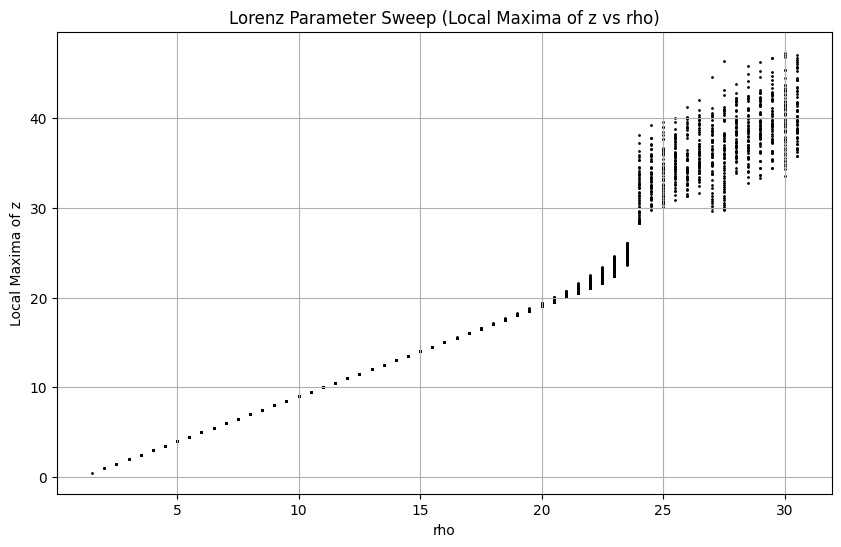

In [10]:
# Sweep rho in Lorenz system
rho_values = np.arange(0, 31, 0.5)
maxima_list = []

for rho_val in rho_values:
    # Use same settings as baseline Lorenz
    sol = solve_ivp(lorenz, (0, 60), state0, args=(10, rho_val, 8/3), max_step=0.05, method='RK45')
    
    # Extract z(t) and discard transient (e.g. first 20 time units)
    valid_idx = sol.t > 20
    z_valid = sol.y[2][valid_idx]
    
    # Find local maxima in z
    peaks, _ = find_peaks(z_valid)
    
    for p in peaks:
        maxima_list.append((rho_val, z_valid[p]))

maxima_arr = np.array(maxima_list)

plt.figure(figsize=(10, 6))
plt.scatter(maxima_arr[:, 0], maxima_arr[:, 1], s=1, color='black')
plt.title('Lorenz Parameter Sweep (Local Maxima of z vs rho)')
plt.xlabel('rho')
plt.ylabel('Local Maxima of z')
plt.show()


### C.2 Step-size Sensitivity


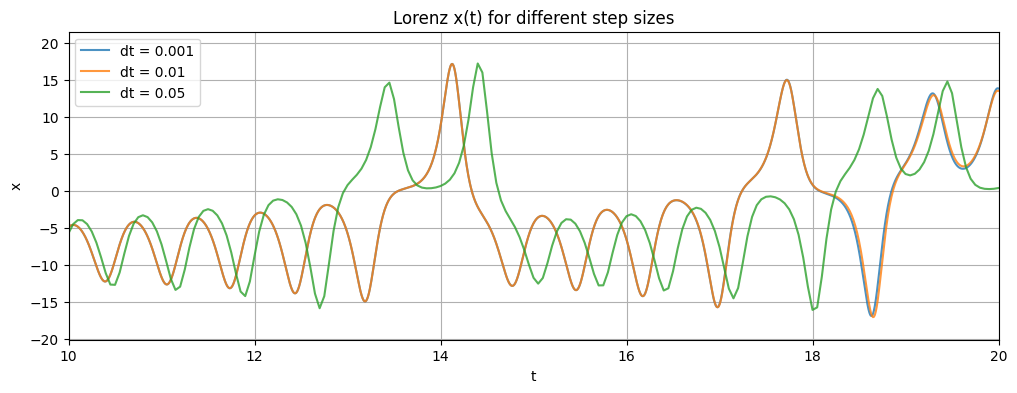

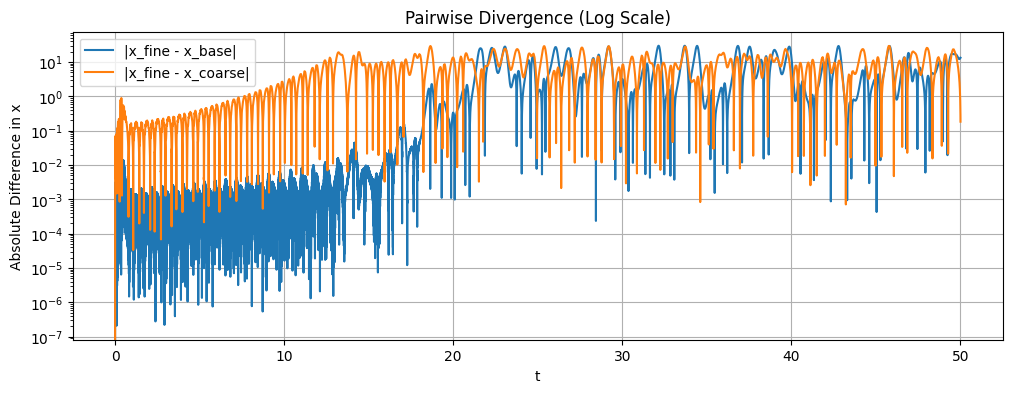

In [11]:
# Re-simulate Lorenz with different time steps (Runge-Kutta 4 fixed step)
def rk4_step(f, t, state, dt, args):
    k1 = np.array(f(t, state, *args))
    k2 = np.array(f(t + dt/2, state + dt*k1/2, *args))
    k3 = np.array(f(t + dt/2, state + dt*k2/2, *args))
    k4 = np.array(f(t + dt, state + dt*k3, *args))
    return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def simulate_rk4(dt):
    t = 0
    state = np.array([1.0, 1.0, 1.0])
    args = (10, 28, 8/3)
    history = [state]
    times = [t]
    
    while t < 50:
        state = rk4_step(lorenz, t, state, dt, args)
        t += dt
        history.append(state)
        times.append(t)
        
    return np.array(times), np.array(history).T

# Note: Using RK4 fixed step to clearly demonstrate the effect of fixed step size changes.
t_fine, y_fine = simulate_rk4(0.001)
t_base, y_base = simulate_rk4(0.01)
t_coarse, y_coarse = simulate_rk4(0.05)

# Overlay x(t)
plt.figure(figsize=(12, 4))
plt.plot(t_fine, y_fine[0], label='dt = 0.001', alpha=0.8)
plt.plot(t_base, y_base[0], label='dt = 0.01', alpha=0.8)
plt.plot(t_coarse, y_coarse[0], label='dt = 0.05', alpha=0.8)
plt.title('Lorenz x(t) for different step sizes')
plt.xlim(10, 20) # Zoom into a region where divergence occurs
plt.xlabel('t')
plt.ylabel('x')
plt.legend()
plt.show()

# Interpolate y_base and y_coarse to the t_fine times to compute pairwise divergence
# We'll compare divergence of the x-coordinate vs t_fine
from scipy.interpolate import interp1d

interp_base = interp1d(t_base, y_base[0], kind='linear')
interp_coarse = interp1d(t_coarse, y_coarse[0], kind='linear')

div_base = np.abs(y_fine[0] - interp_base(t_fine))
div_coarse = np.abs(y_fine[0] - interp_coarse(t_fine))

plt.figure(figsize=(12, 4))
plt.semilogy(t_fine, div_base, label='|x_fine - x_base|')
plt.semilogy(t_fine, div_coarse, label='|x_fine - x_coarse|')
plt.title('Pairwise Divergence (Log Scale)')
plt.xlabel('t')
plt.ylabel('Absolute Difference in x')
plt.legend()
plt.show()
